**Student:** Michele Cristina Otta

# Unsupervised Learning
Data Science Track

In [1]:
from sklearn.datasets import fetch_california_housing
import numpy as np

# load california housing prices dataset
california_housing = fetch_california_housing(as_frame=True)

x = california_housing.data # features
print(x)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [2]:
from sklearn.cluster import KMeans

# use K-means to cluster the data in 10 different groups
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(x)

In [3]:
from sklearn.decomposition import PCA

# use PCA to reduce the data dimensionality to 2 components
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

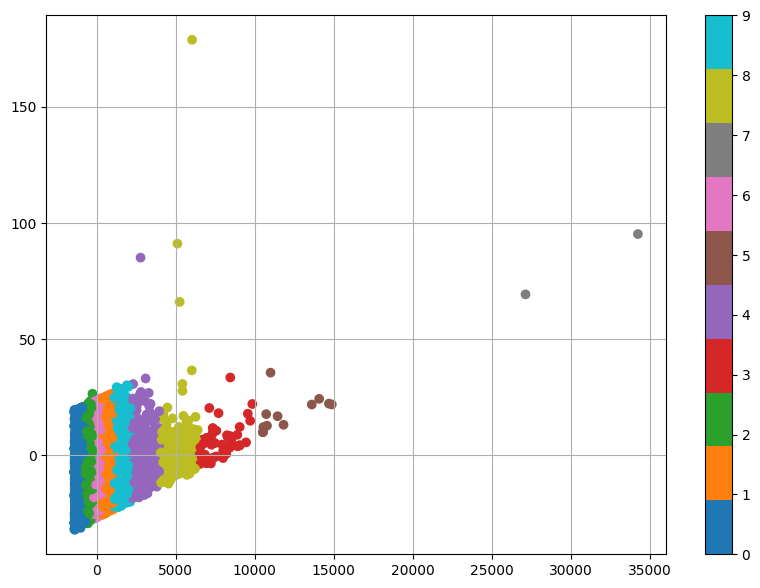

In [4]:
import matplotlib.pyplot as plt

# create scatter plot with the 2D features, colored by group
plt.figure(figsize=(10, 7))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=clusters, cmap='tab10')
plt.colorbar()
plt.grid(True)
plt.show()

In [7]:
# reconstruct the samples to the original dimension and find 3 anomalies

x_reconstructed = pca.inverse_transform(x_pca)
reconstruction_errors = np.linalg.norm(x - x_reconstructed, axis=1)
anomaly_indices = np.argsort(reconstruction_errors)[-3:]

print("Indices of 3 anomalous samples:", anomaly_indices)
print("Reconstruction errors 3 anomalous samples:", reconstruction_errors[anomaly_indices])
x.iloc[anomaly_indices]

Indices of 3 anomalous samples: [16669  3364 19006]
Reconstruction errors 3 anomalous samples: [ 488.90487632  589.01027642 1223.96081873]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98


# References
* [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
* [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
* [Implementation of Principal Component Analysis(PCA) in K Means Clustering](https://medium.com/analytics-vidhya/implementation-of-principal-component-analysis-pca-in-k-means-clustering-b4bc0aa79cb6)